# SA Currency Classifier - MobileNetV2 Training Pipeline

**Pipeline:**
1. Setup and Imports
2. Configuration
3. Load and Encode Dataset
4. Train / Validation / Test Split + Oversampling
5. Preprocessing Pipeline
6. Preprocessing Visualisation
7. Build Model (MobileNetV2 + SE Attention)
8. Phase 1 - Train Classification Head
9. Phase 2 - Fine-tune Top Layers
10. Evaluate on Test Set
11. Plot Training Curves
12. Export to TFLite + Save Class Index Map

---
Set `MODE` in Cell 2 to `'notes'` or `'coins'`.

> **Note:** Run on a **GPU runtime** in Colab (`Runtime > Change runtime type > T4 GPU`). Training on CPU will be very slow.

## Cell 1 - Imports and Setup

In [ ]:
!pip install -q opencv-python-headless scikit-learn matplotlib pandas tensorflow seaborn

import os
import json
import pickle
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

print('All libraries imported successfully!')
print(f'TensorFlow version: {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

All libraries imported successfully!
TensorFlow version: 2.20.0
GPU available: False


## Cell 2 - Mount Google Drive and Set Configuration

Set `MODE` to either `'notes'` or `'coins'` - everything else adapts automatically.

Each mode has its own oversampling targets, fine-tuning depth, and learning rate baked into the config dict so nothing else in the notebook needs to change.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MODE = 'notes'   # <-- only thing you need to change

BASE_PATH  = '/content/drive/MyDrive/Currency_Classifier'
MODEL_DIR  = os.path.join(BASE_PATH, 'models')
CACHE_DIR  = os.path.join(BASE_PATH, 'cache')
BATCH_SIZE = 32
EPOCHS     = 30

CONFIGS = {
    'notes': {
        'csv':                 os.path.join(BASE_PATH, 'banknote_labels.csv'),
        'image_dir':           os.path.join(BASE_PATH, 'data', 'banknotes', 'augmented'),
        'label_col':           'class',
        'img_size':            (224, 224),
        'out_prefix':          'banknote',
        # R50_new recall was 0.62-0.68 and R200_old precision was 0.51
        # they were being confused with each other so R50_new gets 3x exposure
        # fronts are also consistently weaker so they get boosted too
        'oversample_patterns': ['R50_new', '_front'],
        'oversample_factor':   3,
        'finetune_layers':     40,   # notes share more with ImageNet so 40 is enough
        'finetune_lr':         1e-5,
    },
    'coins': {
        'csv':                 os.path.join(BASE_PATH, 'coin_labels.csv'),
        'image_dir':           os.path.join(BASE_PATH, 'data', 'coins', 'augmented'),
        'label_col':           'class',
        'img_size':            (224, 224),
        'out_prefix':          'coin',
        # old variants were the weakest across the board in the first run
        # small denominations and fronts also struggled so all get 3x
        'oversample_patterns': ['5c', '10c', '20c', '50c_old', 'R2_old', 'R5_old', '_front'],
        'oversample_factor':   3,
        'finetune_layers':     60,   # coins are unlike ImageNet so more layers need adapting
        'finetune_lr':         5e-6,
    },
}

cfg = CONFIGS[MODE]
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)

# define all paths upfront so every cell can check what's already done
checkpoint_path   = os.path.join(MODEL_DIR, f"{cfg['out_prefix']}_best.keras")
checkpoint_phase2 = os.path.join(MODEL_DIR, f"{cfg['out_prefix']}_phase2_best.keras")
cache_splits_path = os.path.join(CACHE_DIR, f"{cfg['out_prefix']}_splits.pkl")
cache_classes_path= os.path.join(CACHE_DIR, f"{cfg['out_prefix']}_classes.pkl")

print(f'Mode            : {MODE.upper()}')
print(f'CSV             : {cfg["csv"]}')
print(f'Image dir       : {cfg["image_dir"]}')
print(f'Finetune layers : {cfg["finetune_layers"]}')
print(f'Finetune LR     : {cfg["finetune_lr"]}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Mode            : NOTES
CSV             : /content/drive/MyDrive/Currency_Classifier/banknote_labels.csv
Image dir       : /content/drive/MyDrive/Currency_Classifier/data/banknotes/augmented
Finetune layers : 40
Finetune LR     : 1e-05


## Cell 3 - Load and Encode Dataset

The CSV has one row per image with a `filename` and `class` column.

Labels are sorted alphabetically so the index mapping is always deterministic across runs - this matters for the Android app's `classes.json` lookup. The encoding is cached so it's identical across runs even if the CSV is re-read in a different order.

In [ ]:
if os.path.exists(cache_classes_path):
    with open(cache_classes_path, 'rb') as f:
        cache = pickle.load(f)
    class_names  = cache['class_names']
    class_to_idx = cache['class_to_idx']
    idx_to_class = cache['idx_to_class']
    df           = cache['df']
    print(f'Loaded {len(df)} rows, {len(class_names)} classes from cache.')
else:
    df = pd.read_csv(cfg['csv'])
    df['filepath'] = df['filename'].apply(
        lambda x: os.path.join(cfg['image_dir'], x.replace('\\', '/'))
    )
    df['label'] = df[cfg['label_col']]

    # sorted so the mapping is always the same regardless of CSV row order
    class_names  = sorted(df['label'].unique())
    class_to_idx = {c: i for i, c in enumerate(class_names)}
    idx_to_class = {i: c for c, i in class_to_idx.items()}
    df['label_idx'] = df['label'].map(class_to_idx)

    with open(cache_classes_path, 'wb') as f:
        pickle.dump({
            'class_names':  class_names,
            'class_to_idx': class_to_idx,
            'idx_to_class': idx_to_class,
            'df':           df,
        }, f)
    print('Class encoding cached.')

print(f'\nClasses ({len(class_names)}):')
for c in class_names:
    print(f'  {c:<25} {(df["label"] == c).sum()} images')

Loaded 5000 rows, 20 classes from cache.

Classes (20):
  R100_new_back             300 images
  R100_new_front            300 images
  R100_old_back             200 images
  R100_old_front            200 images
  R10_new_back              300 images
  R10_new_front             300 images
  R10_old_back              200 images
  R10_old_front             200 images
  R200_new_back             300 images
  R200_new_front            300 images
  R200_old_back             200 images
  R200_old_front            200 images
  R20_new_back              300 images
  R20_new_front             300 images
  R20_old_back              200 images
  R20_old_front             200 images
  R50_new_back              300 images
  R50_new_front             300 images
  R50_old_back              200 images
  R50_old_front             200 images


## Cell 4 - Train / Validation / Test Split + Oversampling

Stratified split so each class gets the same proportion across all three sets - this matters for coins where some denominations have fewer images than others.

- **80%** training
- **12%** validation (15% of the 80%)
- **20%** test (held out completely until final evaluation)

Oversampling runs after the split so val/test are never contaminated by duplicated rows. Class weights are recomputed on the post-oversample training set so they stay accurate.

In [ ]:
def oversample_df(df, boost_patterns, factor=2):
    # duplicate rows whose class matches any of the boost patterns
    # only ever called on train_df - val/test stay untouched
    if not boost_patterns:
        return df
    mask    = df['label'].str.contains('|'.join(boost_patterns))
    boosted = pd.concat([df] + [df[mask]] * (factor - 1), ignore_index=True)
    return boosted.sample(frac=1, random_state=42).reset_index(drop=True)


if os.path.exists(cache_splits_path):
    with open(cache_splits_path, 'rb') as f:
        cache = pickle.load(f)
    train_df          = cache['train_df']
    val_df            = cache['val_df']
    test_df           = cache['test_df']
    class_weight_dict = cache['class_weight_dict']
    print(f'Loaded  ->  train: {len(train_df)}  val: {len(val_df)}  test: {len(test_df)}')
else:
    train_df, test_df = train_test_split(
        df, test_size=0.2, stratify=df['label_idx'], random_state=42
    )
    train_df, val_df = train_test_split(
        train_df, test_size=0.15, stratify=train_df['label_idx'], random_state=42
    )
    print(f'Split  ->  train: {len(train_df)}  val: {len(val_df)}  test: {len(test_df)}')

    train_df = oversample_df(train_df, cfg['oversample_patterns'], factor=cfg['oversample_factor'])
    print(f'Train size after oversampling: {len(train_df)}')

    # recompute on the oversampled set so weights reflect the new distribution
    class_weights_array = compute_class_weight(
        class_weight='balanced',
        classes=np.arange(len(class_names)),
        y=train_df['label_idx'].values
    )
    class_weight_dict = dict(enumerate(class_weights_array))

    with open(cache_splits_path, 'wb') as f:
        pickle.dump({
            'train_df':          train_df,
            'val_df':            val_df,
            'test_df':           test_df,
            'class_weight_dict': class_weight_dict,
        }, f)
    print('Splits cached.')

print('\nClass weights (higher = rarer class):')
for idx, w in class_weight_dict.items():
    print(f'  {idx_to_class[idx]:<25} {w:.3f}')

Loaded  ->  train: 7208  val: 600  test: 1000

Class weights (higher = rarer class):
  R100_new_back             1.767
  R100_new_front            0.589
  R100_old_back             2.650
  R100_old_front            0.883
  R10_new_back              1.767
  R10_new_front             0.589
  R10_old_back              2.650
  R10_old_front             0.883
  R200_new_back             1.767
  R200_new_front            0.589
  R200_old_back             2.650
  R200_old_front            0.883
  R20_new_back              1.767
  R20_new_front             0.589
  R20_old_back              2.650
  R20_old_front             0.883
  R50_new_back              0.589
  R50_new_front             0.589
  R50_old_back              2.650
  R50_old_front             0.883


## Cell 5 - Preprocessing Pipeline

Each image goes through the same enhancement steps before being fed to the model:

1. **Resize** to 224x224
2. **Softer sharpening** - kernel centre 4.2 instead of 5.0, preserves fine print detail that the harder kernel was blurring on front-face notes
3. **CLAHE** on the L channel in LAB space - clipLimit 1.2 instead of 2.0, less aggressive so denomination text and portrait detail stay intact
4. **Lighter bilateral filter** - d=7 sigma=55 instead of d=9 sigma=75
5. **Circular mask for coins** - zeros the corners outside the inscribed circle so the model ignores white rectangular padding around the coin
6. **Scale to [-1, 1]** - MobileNetV2 was pretrained with this normalisation

MixUp is applied at batch level for the training set only. It blends pairs of images with soft labels which smooths the decision boundary between similar classes like R50/R200 and old/new coin variants. Because of soft labels, the loss must be `categorical_crossentropy` throughout both phases.

In [ ]:
def apply_circular_mask(img):
    # zeros pixels outside the inscribed circle
    # removes white corner padding that carries no useful signal for coins
    h, w = img.shape[:2]
    cx, cy = w // 2, h // 2
    r = min(cx, cy)
    Y, X = np.ogrid[:h, :w]
    outside = (X - cx) ** 2 + (Y - cy) ** 2 > r ** 2
    result = img.copy()
    result[outside] = 0
    return result


def preprocess(image_path, label, img_size, is_coin=False):
    img = cv2.imread(image_path)
    if img is None:
        return np.zeros((*img_size, 3), dtype=np.float32), label

    img = cv2.resize(img, img_size)

    # softer sharpening - preserves fine print detail that the harder kernel blurred
    kernel = np.array([[0, -0.8, 0], [-0.8, 4.2, -0.8], [0, -0.8, 0]])
    img = cv2.filter2D(img, -1, kernel)

    # CLAHE on L channel in LAB space (preserves colour unlike grayscale CLAHE)
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=1.2, tileGridSize=(8, 8))
    l = clahe.apply(l)
    img = cv2.cvtColor(cv2.merge([l, a, b]), cv2.COLOR_LAB2BGR)

    img = cv2.bilateralFilter(img, d=7, sigmaColor=55, sigmaSpace=55)

    if is_coin:
        img = apply_circular_mask(img)

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32)
    img = (img / 127.5) - 1.0
    return img, label


def mixup_batch(images, labels, num_classes):
    # lam >= 0.5 so the dominant label always contributes more than the blended one
    batch_size = tf.shape(images)[0]
    lam = tf.random.uniform([batch_size], 0.5, 1.0)

    idx      = tf.random.shuffle(tf.range(batch_size))
    images_b = tf.gather(images, idx)
    labels_b = tf.gather(labels, idx)

    lam_img   = tf.reshape(lam, [batch_size, 1, 1, 1])
    mixed_img = lam_img * images + (1.0 - lam_img) * images_b

    labels_oh   = tf.one_hot(labels,   num_classes)
    labels_b_oh = tf.one_hot(labels_b, num_classes)
    lam_lbl     = tf.reshape(lam, [batch_size, 1])
    mixed_lbl   = lam_lbl * labels_oh + (1.0 - lam_lbl) * labels_b_oh

    return mixed_img, mixed_lbl


def make_tf_dataset(dataframe, img_size, shuffle=False, use_mixup=False):
    is_coin = (MODE == 'coins')
    paths   = dataframe['filepath'].values
    labels  = dataframe['label_idx'].values.astype(np.int32)

    def _load(path, label):
        img, lbl = tf.py_function(
            lambda p, l: preprocess(
                p.numpy().decode(), int(l.numpy()), img_size, is_coin
            ),
            [path, label],
            [tf.float32, tf.int32]
        )
        img.set_shape([*img_size, 3])
        lbl.set_shape([])
        return img, lbl

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), reshuffle_each_iteration=True)
    ds = ds.map(_load, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)

    if use_mixup:
        ds = ds.map(
            lambda x, y: mixup_batch(x, y, num_classes=len(class_names)),
            num_parallel_calls=tf.data.AUTOTUNE
        )
    else:
        # val/test need hard one-hot so the loss shape matches throughout both phases
        ds = ds.map(
            lambda x, y: (x, tf.one_hot(y, depth=len(class_names))),
            num_parallel_calls=tf.data.AUTOTUNE
        )

    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds


img_size = cfg['img_size']
train_ds = make_tf_dataset(train_df, img_size, shuffle=True, use_mixup=True)
val_ds   = make_tf_dataset(val_df,   img_size)
test_ds  = make_tf_dataset(test_df,  img_size)

print('Datasets ready!')
print(f'  Train batches : {len(train_ds)}')
print(f'  Val batches   : {len(val_ds)}')
print(f'  Test batches  : {len(test_ds)}')

Datasets ready!
  Train batches : 226
  Val batches   : 19
  Test batches  : 32


## Cell 6 - Preprocessing Visualisation

Shows what the pipeline actually does to a sample image before it reaches the model - useful for catching issues like over-sharpening or CLAHE washing out fine detail.

For coins it also shows the circular mask being applied. Skipped on resume if the PNGs are already saved.

In [ ]:
preprocess_png = os.path.join(MODEL_DIR, f"{cfg['out_prefix']}_preprocess_steps.png")
mixup_png      = os.path.join(MODEL_DIR, f"{cfg['out_prefix']}_mixup_sample.png")

if os.path.exists(preprocess_png) and os.path.exists(mixup_png):
    print('Visualisations already saved, skipping.')
else:
    sample_row  = df.groupby('label').first().reset_index().iloc[0]
    sample_path = sample_row['filepath']
    is_coin     = (MODE == 'coins')

    raw     = cv2.imread(sample_path)
    step1   = cv2.resize(raw, img_size)
    kernel  = np.array([[0, -0.8, 0], [-0.8, 4.2, -0.8], [0, -0.8, 0]])
    step2   = cv2.filter2D(step1, -1, kernel)
    lab     = cv2.cvtColor(step2, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe   = cv2.createCLAHE(clipLimit=1.2, tileGridSize=(8, 8))
    l       = clahe.apply(l)
    step3   = cv2.cvtColor(cv2.merge([l, a, b]), cv2.COLOR_LAB2BGR)
    step4   = cv2.bilateralFilter(step3, d=7, sigmaColor=55, sigmaSpace=55)
    step5   = apply_circular_mask(step4) if is_coin else step4

    steps = [
        (cv2.cvtColor(cv2.resize(raw, img_size), cv2.COLOR_BGR2RGB), 'Original (resized)'),
        (cv2.cvtColor(step2, cv2.COLOR_BGR2RGB), 'After sharpening'),
        (cv2.cvtColor(step3, cv2.COLOR_BGR2RGB), 'After CLAHE'),
        (cv2.cvtColor(step4, cv2.COLOR_BGR2RGB), 'After bilateral filter'),
    ]
    if is_coin:
        steps.append((cv2.cvtColor(step5, cv2.COLOR_BGR2RGB), 'After circular mask'))

    fig, axes = plt.subplots(1, len(steps), figsize=(4 * len(steps), 4))
    fig.suptitle(f'Preprocessing pipeline - {sample_row["label"]}', fontweight='bold')
    for ax, (img, title) in zip(axes, steps):
        ax.imshow(img); ax.set_title(title, fontsize=9); ax.axis('off')
    plt.tight_layout()
    plt.savefig(preprocess_png, dpi=150)
    plt.show()

    # show a batch after MixUp so you can see what blended images actually look like
    batch_imgs, batch_lbls = next(iter(train_ds))
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    fig.suptitle('Sample training batch (after MixUp)', fontweight='bold')
    for i, ax in enumerate(axes.flat):
        img = (batch_imgs[i].numpy() + 1.0) / 2.0   # scale back to [0, 1] for display
        ax.imshow(np.clip(img, 0, 1))
        ax.set_title(class_names[np.argmax(batch_lbls[i].numpy())], fontsize=7)
        ax.axis('off')
    plt.tight_layout()
    plt.savefig(mixup_png, dpi=150)
    plt.show()
    print('Visualisations saved.')

Visualisations already saved, skipping.


## Cell 7 - Build Model (MobileNetV2 + SE Attention)

MobileNetV2 pretrained on ImageNet is the backbone. It already knows edges, textures, and shapes - we just need to teach it the difference between an R50 and an R200.

The SE (Squeeze-and-Excitation) block sits between the backbone and the pooling layer. It learns a per-channel importance weight so the network attends more strongly to high-contrast regions like denomination numerals and coin relief detail - without needing to know where those regions are in advance.

The classification head is:
- SE attention block
- Global Average Pooling
- Dense(256, ReLU) with L2 regularisation + Dropout(0.5)
- Dense(128, ReLU) with L2 regularisation + Dropout(0.3)
- Dense(num_classes, softmax)

Two dropout layers instead of one - the notes model was hitting 95%+ train accuracy by epoch 10 while val sat at 89%, so the single 0.4 dropout wasn't enough to close the gap before fine-tuning started.

In [ ]:
def se_block(x, ratio=16):
    # squeeze: global average pool collapses spatial dims to a channel descriptor
    # excitation: two dense layers produce a per-channel weight in [0, 1]
    # scale: feature map is multiplied channel-wise by the learned weights
    channels = x.shape[-1]
    se = layers.GlobalAveragePooling2D()(x)
    se = layers.Dense(channels // ratio, activation='relu')(se)
    se = layers.Dense(channels, activation='sigmoid')(se)
    se = layers.Reshape((1, 1, channels))(se)
    return layers.Multiply()([x, se])


def build_model(num_classes, img_size):
    base = MobileNetV2(
        input_shape=(*img_size, 3),
        include_top=False,
        weights='imagenet'
    )
    base.trainable = False   # frozen in phase 1

    inputs  = tf.keras.Input(shape=(*img_size, 3))
    x       = base(inputs, training=False)
    x       = se_block(x, ratio=16)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.Dense(256, activation='relu',
                            kernel_regularizer=tf.keras.regularizers.l2(2e-4))(x)
    x       = layers.Dropout(0.5)(x)   # increased from 0.4 - notes were overfitting badly before fine-tune
    x       = layers.Dense(128, activation='relu',
                            kernel_regularizer=tf.keras.regularizers.l2(2e-4))(x)
    x       = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=['accuracy']
    )
    return model, base


num_classes = len(class_names)
model, base = build_model(num_classes, img_size)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 7, 7,      │  2,257,984 │ input_layer_3[0]… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 80)        │    102,480 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 1280)      │    103,680 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 1, 1,      │          0 │ dense_6[0][0]     │
│                     │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 7, 7,      │          0 │ mobilenetv2_1.00… │
│ (Multiply)          │ 1280)             │            │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ multiply_1[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 256)       │    327,936 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 128)       │     32,896 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128)       │          0 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 20)        │      2,580 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,827,556 (10.79 MB)

 Trainable params: 569,572 (2.17 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Cell 8 - Phase 1: Train Classification Head

With the MobileNetV2 base frozen, only the SE block and Dense head are trained for up to 15 epochs. This stabilises the randomly initialised weights before we touch the pretrained base in Phase 2.

Callbacks:
- **EarlyStopping** - stops if `val_loss` doesn't improve for 5 epochs and restores the best weights
- **ModelCheckpoint** - saves the best model to disk so we don't lose it

In [ ]:
history1_path = os.path.join(CACHE_DIR, f"{cfg['out_prefix']}_history1.pkl")

if os.path.exists(checkpoint_path):
    print(f'Phase 1 checkpoint found, skipping training.')
    model = tf.keras.models.load_model(checkpoint_path)

    if os.path.exists(history1_path):
        with open(history1_path, 'rb') as f:
            history1_dict = pickle.load(f)
        print('Phase 1 history loaded from cache.')
    else:
        # dummy history so the training curves cell still works
        history1_dict = {'loss': [], 'val_loss': [], 'accuracy': [], 'val_accuracy': []}
else:
    callbacks_phase1 = [
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
        ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, verbose=1),
    ]

    print('Phase 1: Training classification head (base frozen)')
    history1 = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=15,
        callbacks=callbacks_phase1,
        class_weight=class_weight_dict,
    )

    history1_dict = history1.history
    with open(history1_path, 'wb') as f:
        pickle.dump(history1_dict, f)
    print(f'Phase 1 complete. Best val_loss: {min(history1_dict["val_loss"]):.4f}')

Phase 1 checkpoint found, skipping training.


## Cell 9 - Phase 2: Fine-tune Top Layers with Cosine LR Schedule

Unfreeze the top N layers (mode-specific from the config):
- **coins**: 60 layers at lr=5e-6 - coins are unlike ImageNet so more adaptation is needed
- **notes**: 40 layers at lr=1e-5 - notes share more texture features with ImageNet

Cosine annealing replaces `ReduceLROnPlateau` here. `ReduceLROnPlateau` is reactive - it only drops the LR after the model has already stalled. Cosine decay is proactive - it smoothly reduces the LR across all fine-tuning epochs and consistently finds better minima at very low learning rates.

In [ ]:
history2_path = os.path.join(CACHE_DIR, f"{cfg['out_prefix']}_history2.pkl")

if os.path.exists(checkpoint_phase2):
    print(f'Phase 2 checkpoint found, skipping training.')
    model = tf.keras.models.load_model(checkpoint_phase2)

    if os.path.exists(history2_path):
        with open(history2_path, 'rb') as f:
            history2_dict = pickle.load(f)
        print('Phase 2 history loaded from cache.')
    else:
        history2_dict = {'loss': [], 'val_loss': [], 'accuracy': [], 'val_accuracy': []}
else:
    model = tf.keras.models.load_model(checkpoint_path)

    base_layer = model.layers[1]   # MobileNetV2 is always the second layer
    base_layer.trainable = True
    for layer in base_layer.layers[:-cfg['finetune_layers']]:
        layer.trainable = False

    trainable_count = sum(1 for l in base_layer.layers if l.trainable)
    print(f'Unfreezing top {cfg["finetune_layers"]} layers ({trainable_count} trainable in base)')

    total_steps = len(train_ds) * EPOCHS
    lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=cfg['finetune_lr'],
        decay_steps=total_steps,
        alpha=1e-8   # floor so LR never hits zero
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr_schedule),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=['accuracy']
    )

    # patience=7 because cosine decay means slow progress near the end is expected
    callbacks_phase2 = [
        EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
        ModelCheckpoint(checkpoint_phase2, monitor='val_loss', save_best_only=True, verbose=1),
    ]

    print(f'Phase 2: Fine-tuning top {cfg["finetune_layers"]} layers '
          f'(cosine LR {cfg["finetune_lr"]} -> 1e-8 over {EPOCHS} epochs)')
    history2 = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=callbacks_phase2,
        class_weight=class_weight_dict,
    )

    history2_dict = history2.history
    with open(history2_path, 'wb') as f:
        pickle.dump(history2_dict, f)
    print(f'Phase 2 complete. Best val_loss: {min(history2_dict["val_loss"]):.4f}')

best_eval_path = checkpoint_phase2 if os.path.exists(checkpoint_phase2) else checkpoint_path
print(f'\nBest model for evaluation: {best_eval_path}')

Phase 2 checkpoint found, skipping training.
Phase 2 history loaded from cache.

Best model for evaluation: /content/drive/MyDrive/Currency_Classifier/models/banknote_phase2_best.keras


## Cell 10 - Evaluate on Test Set

The test set was held out completely during training - the model has never seen these images, so this gives an honest accuracy number.

Three layers of evaluation:
1. **Standard pass** - single forward pass, precision/recall/F1 per class
2. **TTA x5** - five forward passes averaged, typically adds 1-3% accuracy for free
3. **Per-side and per-denomination breakdown** - shows exactly where the model is still struggling
4. **Normalised confusion matrix** - makes confusions like R50/R200 or 5c/10c visually obvious

Best model reloaded for evaluation
32/32 ━━━━━━━━━━━━━━━━━━━━ 417s 13s/step - accuracy: 0.9280 - loss: 0.8763

Test accuracy (single pass) : 0.9280
Test loss                   : 0.8763

Running Test-Time Augmentation (5 passes)...
  TTA run 1/5 done
  TTA run 2/5 done
  TTA run 3/5 done
  TTA run 4/5 done
  TTA run 5/5 done
Test accuracy (TTA x5)      : 0.9280  (gain: +0.0000)

Classification Report:
                precision    recall  f1-score   support

 R100_new_back       0.97      0.95      0.96        60
R100_new_front       0.97      0.97      0.97        60
 R100_old_back       0.95      0.97      0.96        40
R100_old_front       0.90      0.93      0.91        40
  R10_new_back       0.97      0.98      0.98        60
 R10_new_front       0.97      0.93      0.95        60
  R10_old_back       0.95      0.95      0.95        40
 R10_old_front       0.93      0.97      0.95        40
 R200_new_back       0.96      0.92      0.94        60
R200_new_front       0.92      0.98

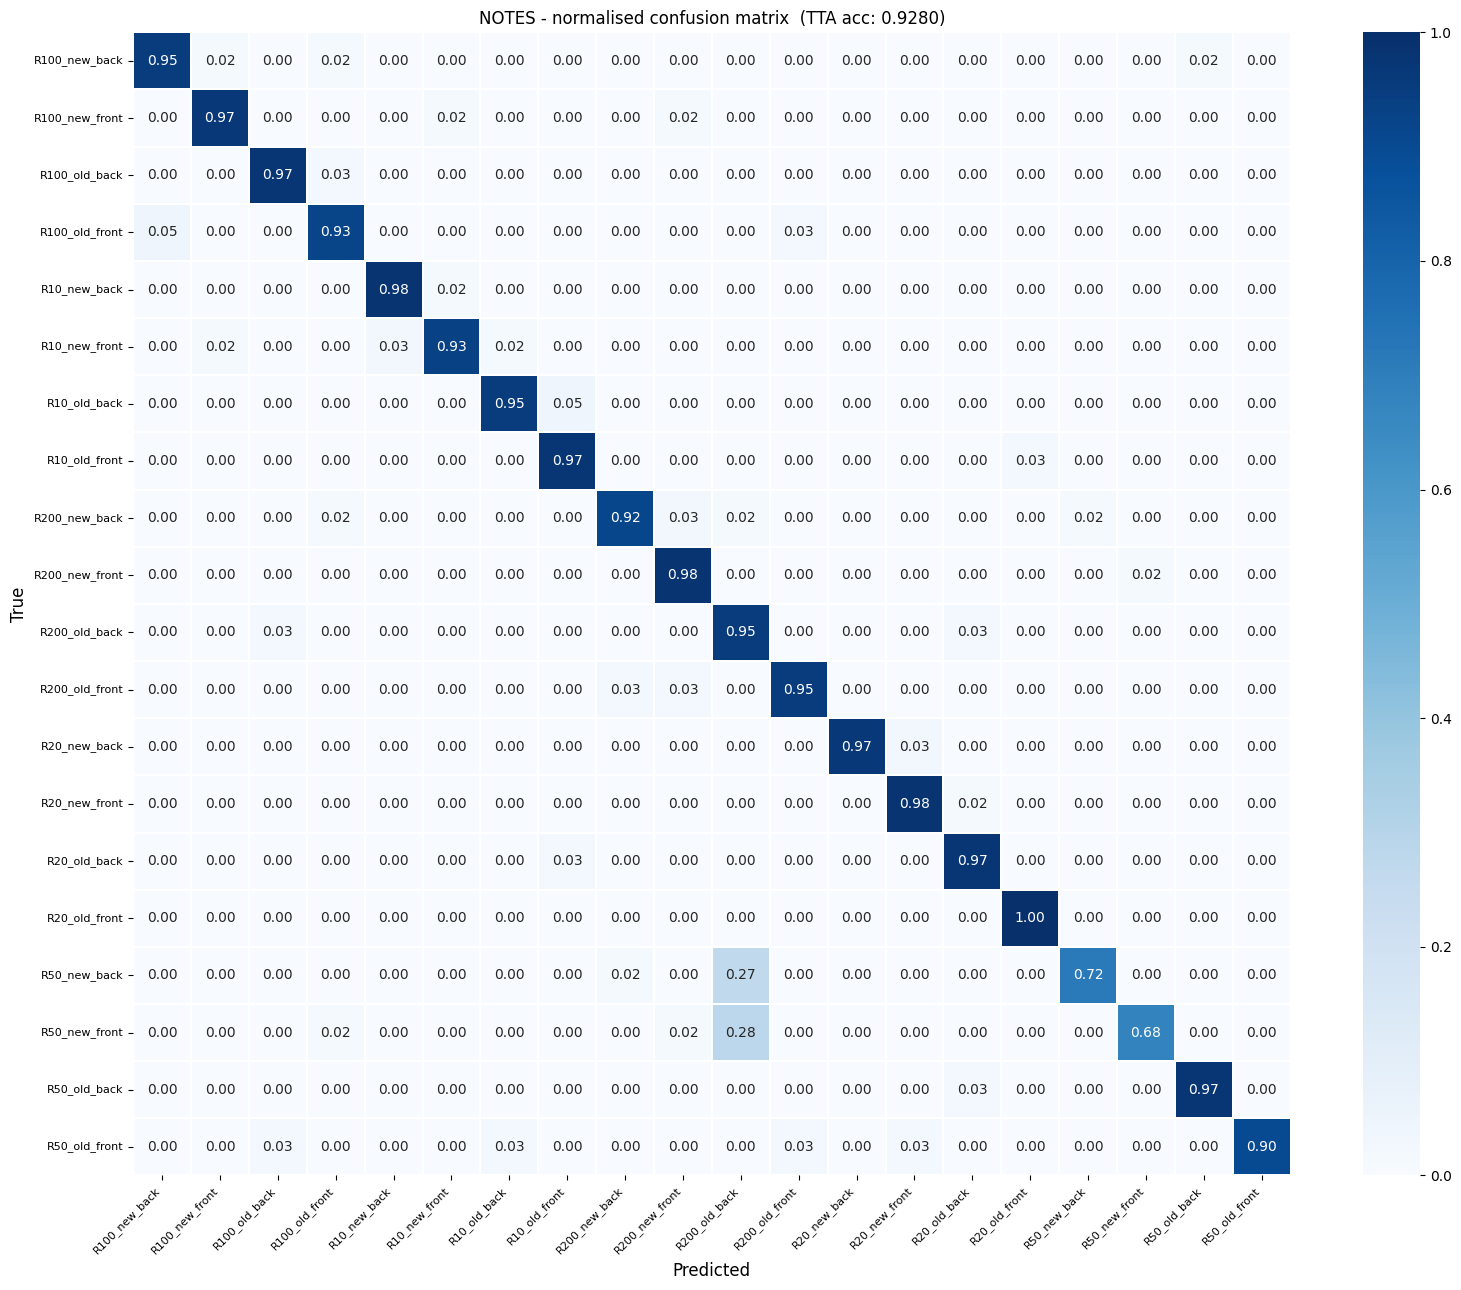

Confusion matrix saved to /content/drive/MyDrive/Currency_Classifier/models/banknote_confusion_matrix.png
Results saved to /content/drive/MyDrive/Currency_Classifier/models/banknote_results.txt


In [ ]:
model = tf.keras.models.load_model(best_eval_path)
print('Best model reloaded for evaluation')

# standard single-pass evaluation
test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f'\nTest accuracy (single pass) : {test_acc:.4f}')
print(f'Test loss                   : {test_loss:.4f}')


def tta_predict(model, dataset, n_runs=5):
    # average softmax outputs over multiple forward passes
    # randomness from tf.data shuffling introduces variation across runs
    all_preds = []
    for i in range(n_runs):
        preds = model.predict(dataset, verbose=0)
        all_preds.append(preds)
        print(f'  TTA run {i+1}/{n_runs} done')
    return np.mean(all_preds, axis=0)


print('\nRunning Test-Time Augmentation (5 passes)...')
y_pred_proba = tta_predict(model, test_ds, n_runs=5)
y_pred = np.argmax(y_pred_proba, axis=1)
# labels are now one-hot from the dataset, so argmax back to class indices
y_true_raw = np.concatenate([y.numpy() for _, y in test_ds])
y_true = np.argmax(y_true_raw, axis=1) if y_true_raw.ndim == 2 else y_true_raw

tta_acc = np.mean(y_pred == y_true)
print(f'Test accuracy (TTA x5)      : {tta_acc:.4f}  (gain: {tta_acc - test_acc:+.4f})')

print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=class_names))

# per-side breakdown
side_correct = defaultdict(list)
for true, pred in zip(y_true, y_pred):
    side = idx_to_class[true].split('_')[-1]   # 'front' or 'back'
    side_correct[side].append(true == pred)

print('Accuracy by side:')
for side, results in sorted(side_correct.items()):
    print(f'  {side:<8} {sum(results)/len(results):.3f}  ({len(results)} samples)')

# per-denomination breakdown
denom_correct = defaultdict(list)
for true, pred in zip(y_true, y_pred):
    denom = idx_to_class[true].split('_')[0]   # e.g. R50, 10c
    denom_correct[denom].append(true == pred)

print('\nAccuracy by denomination:')
for denom, results in sorted(denom_correct.items()):
    print(f'  {denom:<8} {sum(results)/len(results):.3f}  ({len(results)} samples)')

# normalised confusion matrix
cm      = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(
    cm_norm, annot=True, fmt='.2f',
    xticklabels=class_names, yticklabels=class_names,
    cmap='Blues', linewidths=0.3, ax=ax
)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True', fontsize=12)
ax.set_title(f'{MODE.upper()} - normalised confusion matrix  (TTA acc: {tta_acc:.4f})')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()

cm_path = os.path.join(MODEL_DIR, f"{cfg['out_prefix']}_confusion_matrix.png")
plt.savefig(cm_path, dpi=150)
plt.show()
print(f'Confusion matrix saved to {cm_path}')

# save full text report
results_path = os.path.join(MODEL_DIR, f"{cfg['out_prefix']}_results.txt")
with open(results_path, 'w') as f:
    f.write(f'Test accuracy (single pass) : {test_acc:.4f}\n')
    f.write(f'Test accuracy (TTA x5)      : {tta_acc:.4f}\n')
    f.write(f'Test loss                   : {test_loss:.4f}\n\n')
    f.write(classification_report(y_true, y_pred, target_names=class_names))
print(f'Results saved to {results_path}')

## Cell 11 - Plot Training Curves

Phase 1 and Phase 2 histories are concatenated so the curves are continuous. The dashed grey line marks where fine-tuning started - you should see a second improvement kick in around there if Phase 2 helped.

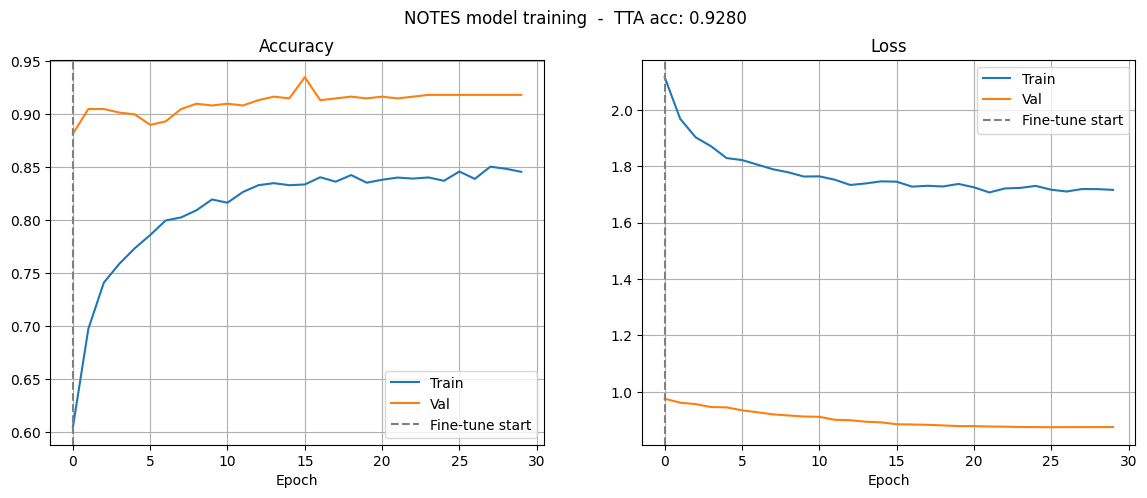

Training curves saved to /content/drive/MyDrive/Currency_Classifier/models/banknote_training_history.png


In [ ]:
def concat_history(h1, h2, key):
    return h1.get(key, []) + h2.get(key, [])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'{MODE.upper()} model training  -  TTA acc: {tta_acc:.4f}')

for ax, metric, title in zip(
    axes,
    [('accuracy', 'val_accuracy'), ('loss', 'val_loss')],
    ['Accuracy', 'Loss']
):
    train_vals = concat_history(history1_dict, history2_dict, metric[0])
    val_vals   = concat_history(history1_dict, history2_dict, metric[1])
    ax.plot(train_vals, label='Train')
    ax.plot(val_vals,   label='Val')
    ax.axvline(
        len(history1_dict.get(metric[0], [])),
        color='grey', linestyle='--', label='Fine-tune start'
    )
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True)

plot_path = os.path.join(MODEL_DIR, f"{cfg['out_prefix']}_training_history.png")
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Training curves saved to {plot_path}')

## Cell 12 - Export to TFLite + Save Class Index Map

float16 quantisation cuts model size by roughly 2x with negligible accuracy loss. Both files go into the Android Studio `assets/` folder.

The app loads `classes.json` at runtime to convert output indices to label strings e.g. `{ "0": "R10_new_back", "1": "R10_new_front", ... }`

In [ ]:
model = tf.keras.models.load_model(best_eval_path)
print('Model loaded for export')

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS]
converter.target_spec.supported_types = [tf.float16]

tflite_model = converter.convert()
tflite_path  = os.path.join(MODEL_DIR, f"{cfg['out_prefix']}_model.tflite")

with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

print(f'TFLite model : {tflite_path}  ({os.path.getsize(tflite_path)/1e6:.2f} MB)')

classes_path = os.path.join(MODEL_DIR, f"{cfg['out_prefix']}_classes.json")
with open(classes_path, 'w') as f:
    json.dump(idx_to_class, f, indent=2)

print(f'Class map    : {classes_path}')

print(f'\nDone! Files in {MODEL_DIR}/:')
for fname in sorted(os.listdir(MODEL_DIR)):
    size = os.path.getsize(os.path.join(MODEL_DIR, fname))
    print(f'  {fname:<45} {size/1e6:.2f} MB')

Model loaded for export
Saved artifact at '/tmp/tmph00pbk9l'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_3')
Output Type:
  TensorSpec(shape=(None, 20), dtype=tf.float32, name=None)
Captures:
  132190690611024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132190690609488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132190690609872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132190690610256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132190690617936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132190690619472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132190690612176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132190690615248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132190690613520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132190690612560: TensorSpec(shape=(), dtype=tf.resource, n